Found!

5 Data Pertama:


,id_transaksi,tanggal,kota,kategori,produk,jumlah,harga_satuan,diskon_persen,metode_pembayaran,rating
0,TRX-0001,2026-02-10,Denpasar,Makanan,Mi Instan,1,"Rp13,000",10%,Tunai,3.9
1,TRX-0002,2026-01-28,Denpasar,Makanan,Kopi,2,"Rp29,000",0%,Tunai,3.4
2,TRX-0003,2026-02-11,Denpasar,Minuman,Air Mineral,2,"Rp7,000",10%,QRIS,5.0
3,TRX-0004,2026-01-22,Surabaya,Makanan,Kopi,1,"Rp28,500",0%,Tunai,4.2
4,TRX-0005,2026-02-24,Surabaya,Makanan,Roti,3,"Rp18,500",5%,QRIS,4.6



Jumlah Baris: 151
Jumlah Kolom: 10

Nama Kolom:
['id_transaksi', 'tanggal', 'kota', 'kategori', 'produk', 'jumlah', 'harga_satuan', 'diskon_persen', 'metode_pembayaran', 'rating']

Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_transaksi       151 non-null    object 
 1   tanggal            151 non-null    object 
 2   kota               151 non-null    object 
 3   kategori           151 non-null    object 
 4   produk             151 non-null    object 
 5   jumlah             151 non-null    int64  
 6   harga_satuan       151 non-null    object 
 7   diskon_persen      151 non-null    object 
 8   metode_pembayaran  151 non-null    object 
 9   rating             148 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 11.9+ KB

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
jumlah,151.0,2.423841,1.224402,1.0,1.0,2.0,3.0,5.0
rating,148.0,4.209459,0.417530,3.2,3.9,4.2,4.5,5.0



Jumlah Nilai Kosong:


...


Jumlah Baris Duplikat:
1

Data Duplikat:


,id_transaksi,tanggal,kota,kategori,produk,jumlah,harga_satuan,diskon_persen,metode_pembayaran,rating
39,TRX-0040,2026-02-13,Makassar,Minuman,Air Mineral,1,"Rp6,000",10%,Tunai,4.6
150,TRX-0040,2026-02-13,Makassar,Minuman,Air Mineral,1,"Rp6,000",10%,Tunai,4.6



Jumlah ID Transaksi Duplikat:
1

ID Transaksi yang Duplikat:


,id_transaksi,tanggal,kota,kategori,produk,jumlah,harga_satuan,diskon_persen,metode_pembayaran,rating
39,TRX-0040,2026-02-13,Makassar,Minuman,Air Mineral,1,"Rp6,000",10%,Tunai,4.6
150,TRX-0040,2026-02-13,Makassar,Minuman,Air Mineral,1,"Rp6,000",10%,Tunai,4.6



Kolom Numerik:
['jumlah', 'rating']


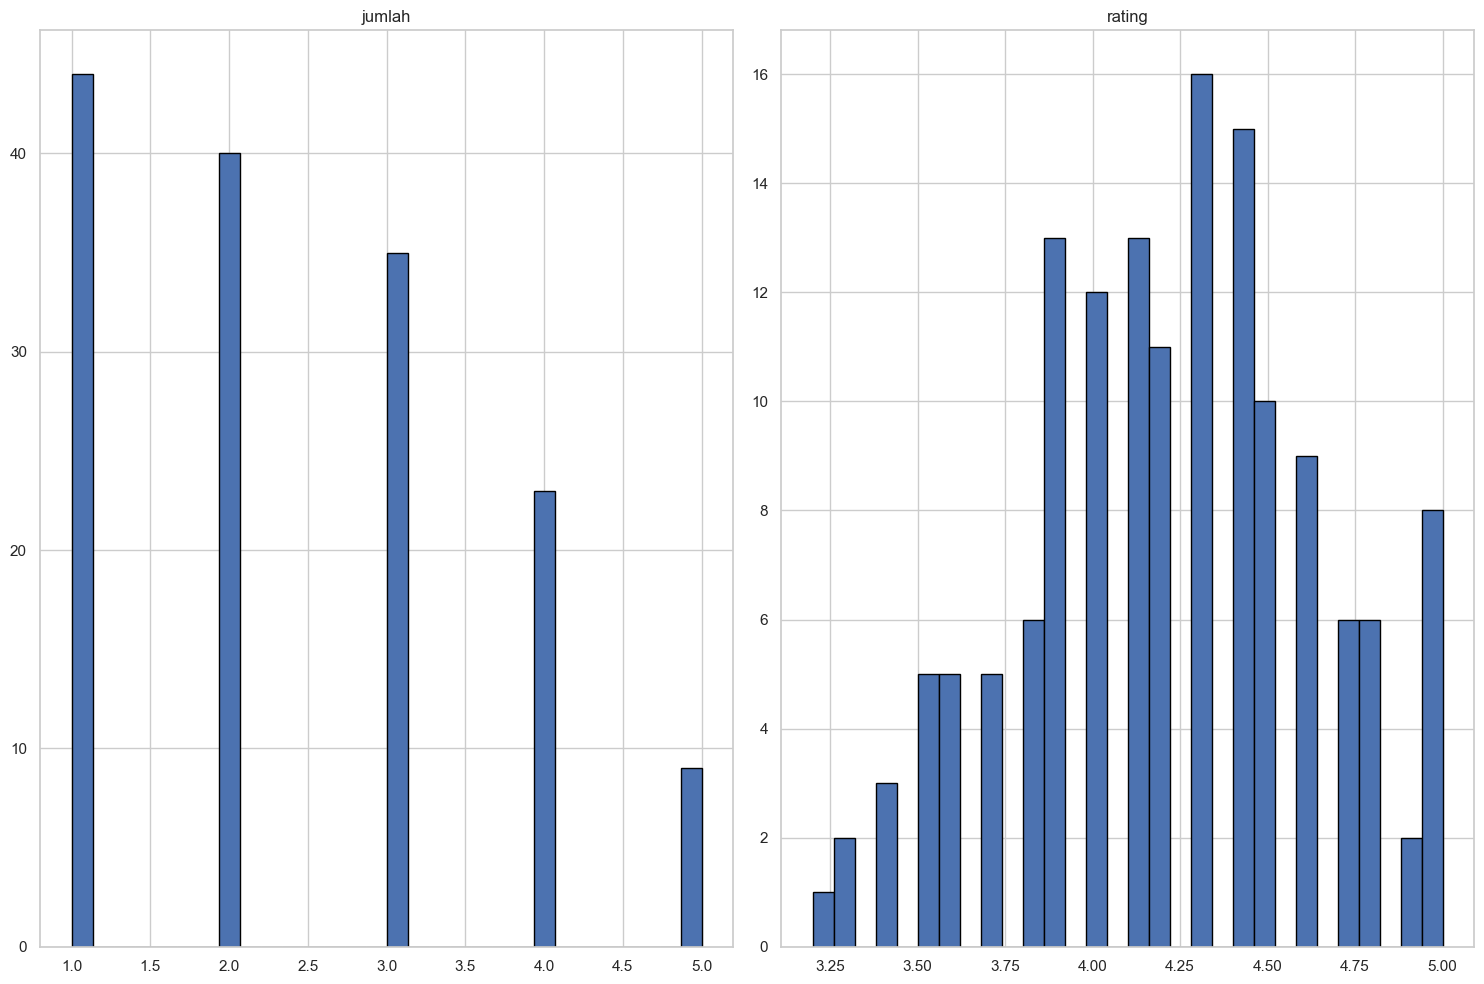

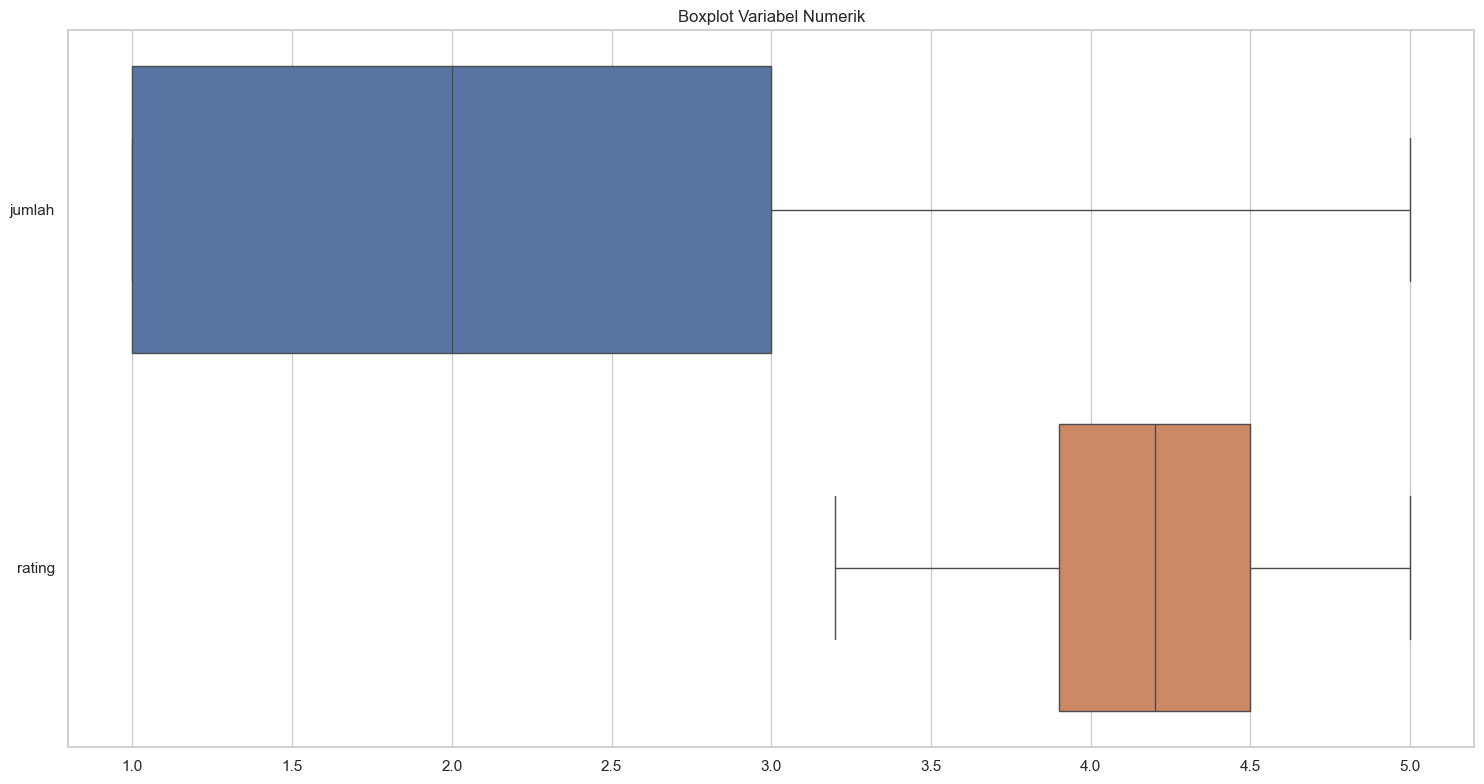

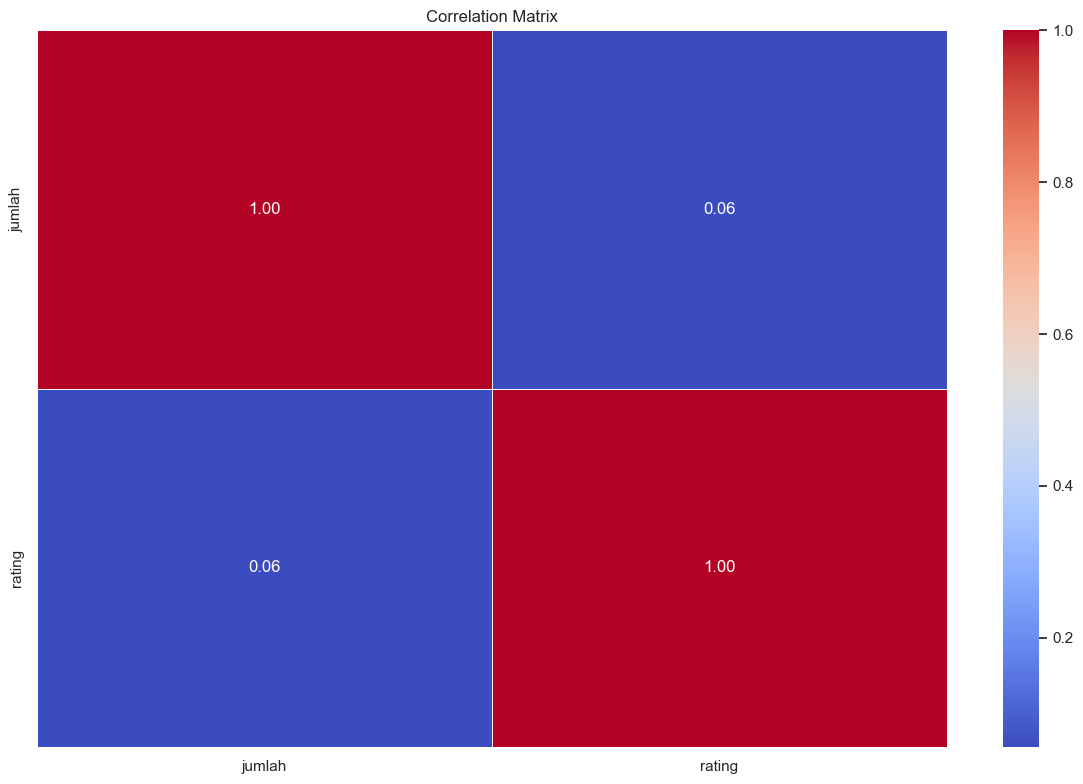

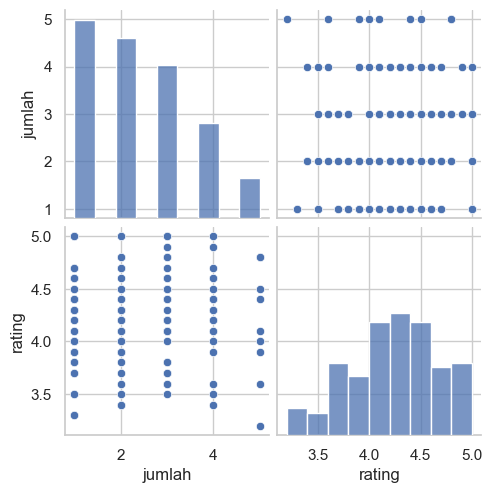

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# ============================================================
# IMPORT FILE
# ============================================================

DATA_TRX = Path(
    r"C:\Users\Salsa\OneDrive\Documents\Sheilla\Learning\Data_Analytics\Python\Studi_Kasus_EDA_Data_Penjualan.csv"
)

# Check if file exists
assert DATA_TRX.exists(), 'File Not Found'
print('Found!')

# ============================================================
# READ FILE
# ============================================================

# Karena file adalah CSV, gunakan read_csv()
rf = pd.read_csv(DATA_TRX)

# Melihat 5 data pertama
print('\n5 Data Pertama:')
display(rf.head())

# ============================================================
# INFORMASI DATA
# ============================================================

print('\nJumlah Baris:', rf.shape[0])
print('Jumlah Kolom:', rf.shape[1])

print('\nNama Kolom:')
print(rf.columns.tolist())

# Melihat tipe data
print('\nTipe Data:')
rf.info()

# ============================================================
# STATISTIK DESKRIPTIF
# ============================================================

print('\nStatistik Deskriptif:')
display(rf.describe().T)

# ============================================================
# EDA
# ============================================================

# Jumlah nilai kosong
print('\nJumlah Nilai Kosong:')
display(
    rf.isna()
      .sum()
      .to_frame('jumlah_kosong')
      .sort_values('jumlah_kosong', ascending=False)
)

# Persentase nilai kosong
print('\nPersentase Nilai Kosong:')
missing_pct = (
    rf.isna()
      .mean()
      .mul(100)
      .to_frame('persentase_kosong')
      .sort_values('persentase_kosong', ascending=False)
)

display(missing_pct)

# ============================================================
# DUPLICATE
# ============================================================

print('\nJumlah Baris Duplikat:')
print(rf.duplicated().sum())

# Melihat data yang terduplikasi
duplicate_rows = rf[rf.duplicated(keep=False)]

if not duplicate_rows.empty:
    print('\nData Duplikat:')
    display(duplicate_rows)
else:
    print('Tidak ada data duplikat.')

# ============================================================
# DUPLICATE BERDASARKAN ID TRANSAKSI
# ============================================================

if 'id_transaksi' in rf.columns:
    print('\nJumlah ID Transaksi Duplikat:')
    print(rf['id_transaksi'].duplicated().sum())

    print('\nID Transaksi yang Duplikat:')
    duplicate_transaction = (
        rf[rf['id_transaksi'].duplicated(keep=False)]
        .sort_values('id_transaksi')
    )

    if not duplicate_transaction.empty:
        display(duplicate_transaction)
    else:
        print('Tidak ada ID transaksi yang duplikat.')
else:
    print("\nKolom 'id_transaksi' tidak ditemukan.")

# ============================================================
# DISTRIBUSI DATA NUMERIK
# ============================================================

numeric_columns = rf.select_dtypes(include=np.number).columns

if len(numeric_columns) > 0:
    print('\nKolom Numerik:')
    print(numeric_columns.tolist())

    rf[numeric_columns].hist(
        figsize=(15, 10),
        bins=30,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# BOXPLOT
# ============================================================

if len(numeric_columns) > 0:
    plt.figure(figsize=(15, 8))

    sns.boxplot(
        data=rf[numeric_columns],
        orient='h'
    )

    plt.title('Boxplot Variabel Numerik')
    plt.tight_layout()
    plt.show()

# ============================================================
# CORRELATION
# ============================================================

if len(numeric_columns) > 1:
    plt.figure(figsize=(12, 8))

    correlation = rf[numeric_columns].corr()

    sns.heatmap(
        correlation,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=0.5
    )

    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

# ============================================================
# SEABORN PAIRPLOT
# ============================================================

if len(numeric_columns) > 1:
    sns.pairplot(
        rf[numeric_columns].dropna()
    )

    plt.show()